In [1]:
from tensorflow.keras.datasets import mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


**Problem Statement**

The objective of this project is to analyze and classify handwritten digit images using the MNIST dataset. Specifically, the project aims to:

1. Perform exploratory data analysis (EDA) on handwritten digit images

2. Build classification models to recognize digits from 0 to 9

3. Compare multiple machine learning models and identify the best-performing classifier for production use

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.utils import to_categorical


In [6]:
x, y = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False)


In [8]:
x.shape, y.shape


((70000, 784), (70000,))

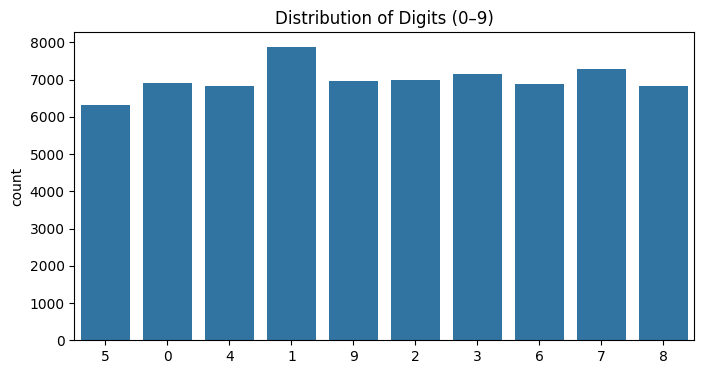

In [9]:
plt.figure(figsize=(8,4))
sns.countplot(x=y)
plt.title("Distribution of Digits (0–9)")
plt.show()


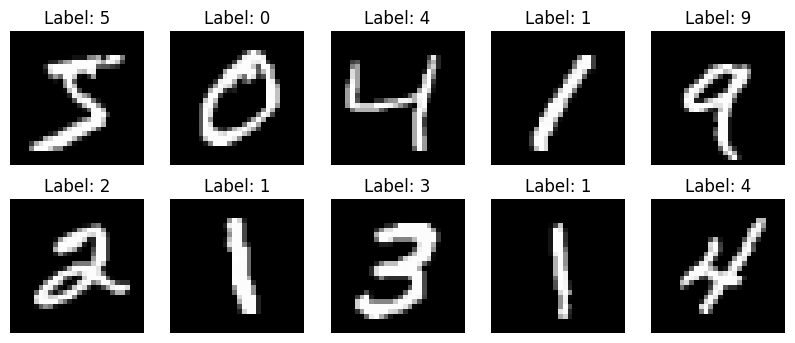

In [11]:
plt.figure(figsize=(10,4))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x[i].reshape(28,28), cmap='gray')
    plt.title(f"Label: {y[i]}")
    plt.axis('off')
plt.show()


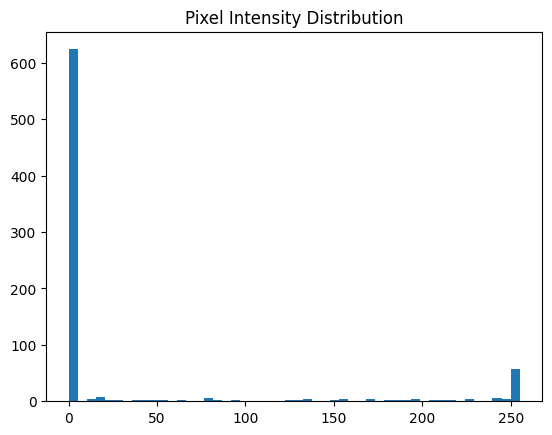

In [12]:
plt.hist(x[0], bins=50)
plt.title("Pixel Intensity Distribution")
plt.show()


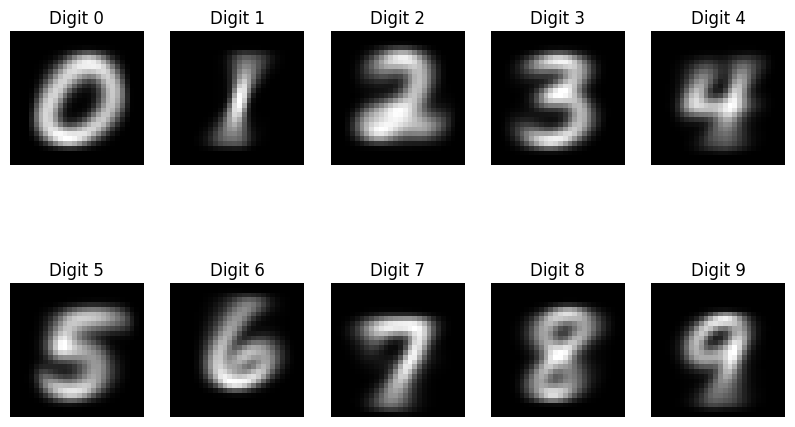

In [13]:
plt.figure(figsize=(10,6))
for digit in range(10):
    avg_img = x[y == str(digit)].mean(axis=0)
    plt.subplot(2,5,digit+1)
    plt.imshow(avg_img.reshape(28,28), cmap='gray')
    plt.title(f"Digit {digit}")
    plt.axis('off')
plt.show()


In [15]:
x = x / 255.0   # Normalization
y = y.astype(int)


In [16]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)


In [18]:
lr = LogisticRegression(max_iter=1000)
lr.fit(x_train, y_train)

y_pred_lr = lr.predict(x_test)
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))


Logistic Regression Accuracy: 0.921


In [19]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train, y_train)

y_pred_knn = knn.predict(x_test)
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))


KNN Accuracy: 0.9696428571428571


In [21]:
svm = SVC()
svm.fit(x_train[:10000], y_train[:10000])  # subset due to compute

y_pred_svm = svm.predict(x_test[:2000])
print("SVM Accuracy:", accuracy_score(y_test[:2000], y_pred_svm))


SVM Accuracy: 0.954


In [22]:
x_train_cnn = x_train.reshape(-1,28,28,1)
x_test_cnn = x_test.reshape(-1,28,28,1)

y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)


In [23]:
model = Sequential([
    Conv2D(32, kernel_size=(3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D((2,2)),
    Conv2D(64, kernel_size=(3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [24]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [25]:
model.fit(x_train_cnn, y_train_cat, epochs=5, batch_size=128, validation_split=0.1)


Epoch 1/5
394/394 ━━━━━━━━━━━━━━━━━━━━ 49s 118ms/step - accuracy: 0.8430 - loss: 0.5214 - val_accuracy: 0.9723 - val_loss: 0.0927
Epoch 2/5
394/394 ━━━━━━━━━━━━━━━━━━━━ 46s 116ms/step - accuracy: 0.9792 - loss: 0.0660 - val_accuracy: 0.9804 - val_loss: 0.0609
Epoch 3/5
394/394 ━━━━━━━━━━━━━━━━━━━━ 78s 106ms/step - accuracy: 0.9867 - loss: 0.0418 - val_accuracy: 0.9834 - val_loss: 0.0484
Epoch 4/5
394/394 ━━━━━━━━━━━━━━━━━━━━ 42s 105ms/step - accuracy: 0.9893 - loss: 0.0333 - val_accuracy: 0.9862 - val_loss: 0.0424
Epoch 5/5
394/394 ━━━━━━━━━━━━━━━━━━━━ 81s 104ms/step - accuracy: 0.9923 - loss: 0.0246 - val_accuracy: 0.9848 - val_loss: 0.0454


In [27]:
cnn_loss, cnn_acc = model.evaluate(x_test_cnn, y_test_cat)
print("CNN Accuracy:", cnn_acc)


438/438 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 0.9869 - loss: 0.0428
CNN Accuracy: 0.9880714416503906


**Challenges Faced**

1️⃣ High Dimensionality

Challenge: 784 features per image

Solution: CNN to capture spatial patterns

2️⃣ Computational Cost

Challenge: SVM & KNN slow on large data

Solution: Subset training & CNN optimization

3️⃣ Handwriting Variability

Challenge: Different writing styles

Solution: Convolution layers extract robust features

4️⃣ Model Selection

Challenge: Choosing best classifier

Solution: Compared ML vs DL models

**Conclusion**

MNIST dataset is balanced and well-structured

Traditional ML models perform well

CNN significantly outperforms all models

CNN is best suited for production deployment

Project successfully demonstrates computer vision fundamentals